# 日常回测控制台

这份 notebook 用于**日常使用**，目标是尽量少切换 cell，直接完成：

1. 读取本地市场数据  
2. 设置资产池与回测参数  
3. 运行风险平价回测  
4. 查看关键结果  
5. 导出回测结果

> 依赖：`market_data.py`、`backtest.py`、`risk_parity.py`


In [ ]:

import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from market_data import create_manager, today_str, load_tushare_token
from backtest import build_market_matrices, simulate_risk_parity_backtest, calc_drawdown

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

# ========= 路径与连接 =========
TUSHARE_TOKEN = load_tushare_token()
DB_PATH = "data/db/market_data.db"
EXPORT_DIR = Path("data/exports")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

manager = create_manager(
    tushare_token=TUSHARE_TOKEN,
    db_path=DB_PATH,
    default_start_date="20150101",
    default_exchange="SSE",
)

print("manager ready")
print("db_path =", Path(DB_PATH).resolve())
print("export_dir =", EXPORT_DIR.resolve())


manager ready
db_path = D:\codeWork\RiskParity\data\db\market_data.db
export_dir = D:\codeWork\RiskParity\data\exports


In [ ]:

# ========= 资产池 =========

#以下为无杠杆全天候国内260324版本
WATCHLIST = [
    "510300.SH",  # 沪深300ETF (核心权益：大盘蓝筹)
    "510500.SH",  # 中证500ETF (核心权益：中盘成长)
    "510170.SH",  # 50ETF (核心权益：大宗商品股票集合)
    "159915.SZ",  # 创业板ETF (核心权益：高新成长 - 纯被动)
    "511090.SH",  # 30年国债ETF (避险资产：超长债，对利率极度敏感)
    "511010.SH",  # 国债ETF (基础配置：中长期债)
    "518880.SH",  # 黄金ETF (抗通胀/避险：金属商品)
    "159981.SZ",  # 能源ETF (抗通胀：能源/电力)
    "159985.SZ",  # 豆粕ETF (抗通胀：农产品期货)
    "501018.SH",  # 南方原油LOF (抗通胀：国际原油价格)
]
# ========= 数据区间 =========
START_DATE = "20070101"
END_DATE = today_str()

# ========= 回测参数 =========
BACKTEST_PARAMS = {
    "initial_cash": 15_000.0,
    "lookback_window": 120,
    "rebalance_freq": "Q",          # D / W / M / Q / Y
    "execution_price_type": "avg",  # open / close / high / low / avg
    "fee_rate_buy": 0.0005,
    "fee_rate_sell": 0.0005,
    "lot_size": 100,
    "max_trade_amount_ratio": 0.05,
    "amount_unit_scale": 1000.0,# 按照tushare文档，单位似乎是千元？
    "use_drift_trigger": False,
    "drift_threshold": 0.05,
    "risk_free_rate": 0.0,
    "annualization": 252,
}

RP_PREPARE_KWARGS = {
    "ffill": True,
    "ffill_limit": 5,
    "min_non_na_ratio": 0.8,
    "drop_all_na_dates": True,

}
valuation_ffill_limit = 5
RP_WEIGHT_KWARGS = {
    "method": "sample",      # sample / ewma
    "return_type": "log",    # log / simple
    "annualization": 252,
    "long_only": True,
    "drop_any_na": True,
}

print("watchlist =", WATCHLIST)
print("params loaded")


watchlist = ['510300.SH', '510500.SH', '510170.SH', '159915.SZ', '511090.SH', '511010.SH', '518880.SH', '159981.SZ', '159985.SZ', '501018.SH']
params loaded


In [3]:

# ========= 读取市场数据并构建 market 字典 =========
raw_prices = manager.store.get_daily_prices(
    ts_codes=WATCHLIST,
    start_date=START_DATE,
    end_date=END_DATE,
)

print("raw_prices shape =", raw_prices.shape)
display(raw_prices.head())

coverage = raw_prices.groupby("ts_code")["trade_date"].agg(["min", "max", "count"])
display(coverage)

market = build_market_matrices(
    data=raw_prices,
    fields=("open", "high", "low", "close", "amount"),
    date_col="trade_date",
    code_col="ts_code",
    date_format="%Y%m%d",
)

RP_PREPARE_KWARGS["calendar"] = market["close"].index

for k, v in market.items():
    print(k, v.shape)


raw_prices shape = (25911, 14)


,ts_code,trade_date,open,high,low,close,pre_close,change,pct_chg,vol,amount,source,created_at,updated_at
0,159915.SZ,20111209,0.795,0.814,0.795,0.797,0.810,-0.013,-1.6049,1061772.33,85143.9790,tushare,2026-03-24 23:15:12,2026-03-24 23:15:12
1,159915.SZ,20111212,0.790,0.803,0.790,0.790,0.797,-0.007,-0.8783,311065.09,24856.6952,tushare,2026-03-24 23:15:12,2026-03-24 23:15:12
2,159915.SZ,20111213,0.788,0.788,0.763,0.768,0.790,-0.022,-2.7848,967443.68,74527.4886,tushare,2026-03-24 23:15:12,2026-03-24 23:15:12
3,159915.SZ,20111214,0.768,0.777,0.755,0.760,0.768,-0.008,-1.0417,816094.68,62820.1826,tushare,2026-03-24 23:15:12,2026-03-24 23:15:12
4,159915.SZ,20111215,0.755,0.764,0.747,0.752,0.760,-0.008,-1.0526,417005.01,31372.8896,tushare,2026-03-24 23:15:12,2026-03-24 23:15:12


,min,max,count
ts_code,,,
159915.SZ,20111209,20260324,3466
159981.SZ,20200117,20260324,1495
159985.SZ,20191205,20260324,1525
501018.SH,20160628,20260323,2362
510170.SH,20110125,20260324,3640
510300.SH,20120528,20260324,3358
510500.SH,20130315,20260324,3161
511010.SH,20130325,20260324,3157
511090.SH,20230613,20260324,672


open (3680, 10)
high (3680, 10)
low (3680, 10)
close (3680, 10)
amount (3680, 10)


In [4]:

# ========= 运行回测 =========
result = simulate_risk_parity_backtest(
    market=market,
    initial_cash=BACKTEST_PARAMS["initial_cash"],
    lookback_window=BACKTEST_PARAMS["lookback_window"],
    rebalance_freq=BACKTEST_PARAMS["rebalance_freq"],
    execution_price_type=BACKTEST_PARAMS["execution_price_type"],
    fee_rate_buy=BACKTEST_PARAMS["fee_rate_buy"],
    fee_rate_sell=BACKTEST_PARAMS["fee_rate_sell"],
    lot_size=BACKTEST_PARAMS["lot_size"],
    max_trade_amount_ratio=BACKTEST_PARAMS["max_trade_amount_ratio"],
    amount_unit_scale=BACKTEST_PARAMS["amount_unit_scale"],
    use_drift_trigger=BACKTEST_PARAMS["use_drift_trigger"],
    drift_threshold=BACKTEST_PARAMS["drift_threshold"],
    rp_prepare_kwargs=RP_PREPARE_KWARGS,
    rp_weight_kwargs=RP_WEIGHT_KWARGS,
    risk_free_rate=BACKTEST_PARAMS["risk_free_rate"],
    annualization=BACKTEST_PARAMS["annualization"],
    valuation_ffill_limit=valuation_ffill_limit,
)

summary = result["summary"]
nav_df = result["nav_df"]
returns = result["returns"]
weights_df = result["weights_df"]
positions_df = result["positions_df"]
target_weights_df = result["target_weights_df"]
trades_df = result["trades_df"]
rebalance_log_df = result["rebalance_log_df"]

print("回测完成")
display(summary.to_frame("value"))


回测完成


,value
total_return,1.154743
annual_return,0.053990
annual_volatility,0.110224
sharpe_ratio,0.531516
max_drawdown,-0.317777


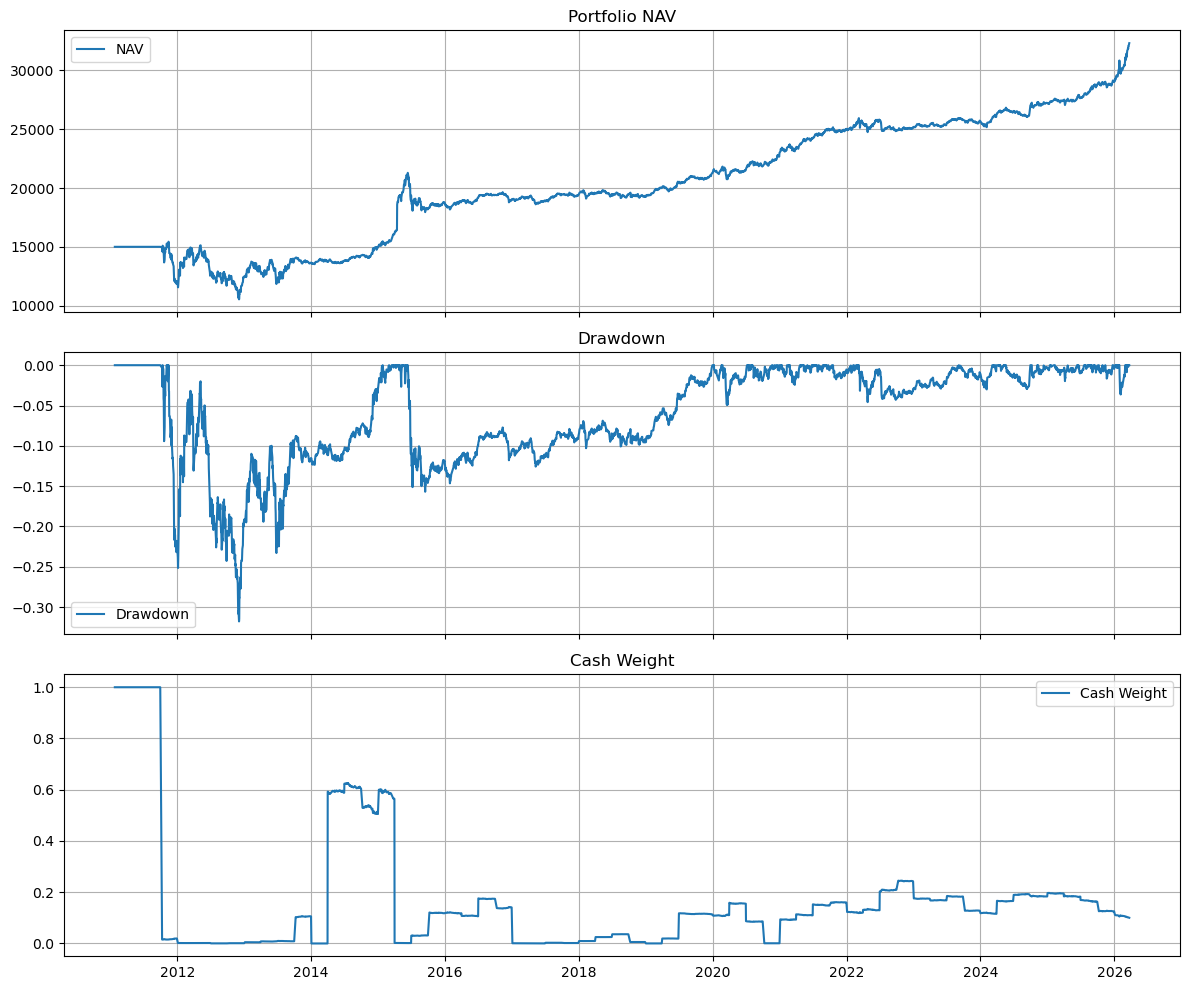

最近净值：


,nav,cash
trade_date,,
2026-03-18,31845.345813,3243.445813
2026-03-19,32063.445813,3243.445813
2026-03-20,32058.045813,3243.445813
2026-03-23,32265.745813,3243.445813
2026-03-24,32321.145813,3243.445813


最近现金占比：


,cash_weight
trade_date,
2026-03-18,0.101850
2026-03-19,0.101157
2026-03-20,0.101174
2026-03-23,0.100523
2026-03-24,0.100351


最近目标权重：


...

最近调仓日志：


,signal_date,trade_date,reason,drift_value,turnover,cash_after_trade,traded,trade_count
48,2023-09-28,2023-10-09,schedule,NaN,0.073516,3284.871163,1,12
49,2023-12-29,2024-01-02,schedule,NaN,0.045957,3032.573250,1,18
50,2024-03-29,2024-04-01,schedule,NaN,0.076518,4388.815263,1,16
51,2024-06-28,2024-07-01,schedule,NaN,0.069198,5027.590075,1,14
52,2024-09-30,2024-10-08,schedule,NaN,0.083394,4995.745688,1,15
53,2024-12-31,2025-01-02,schedule,NaN,0.037601,5359.087550,1,15
54,2025-03-31,2025-04-01,schedule,NaN,0.024927,5056.304200,1,14
55,2025-06-30,2025-07-01,schedule,NaN,0.130415,4695.612025,1,13
56,2025-09-30,2025-10-09,schedule,NaN,0.052514,3649.823538,1,21
57,2025-12-31,2026-01-05,schedule,NaN,0.078037,3243.445813,1,23


最近交易记录：


,trade_date,ts_code,side,price,shares,trade_value,cost
838,2026-01-05,510500.SH,SELL,7.71700,100,771.700,0.385850
839,2026-01-05,511010.SH,SELL,140.02475,100,14002.475,7.001238
840,2026-01-05,518880.SH,SELL,9.45900,100,945.900,0.472950
841,2026-01-05,511010.SH,BUY,140.02475,100,14002.475,7.001238
842,2026-01-05,501018.SH,BUY,1.10975,100,110.975,0.055487
843,2026-01-05,501018.SH,BUY,1.10975,100,110.975,0.055487
844,2026-01-05,501018.SH,BUY,1.10975,100,110.975,0.055487
845,2026-01-05,501018.SH,BUY,1.10975,100,110.975,0.055487
846,2026-01-05,501018.SH,BUY,1.10975,100,110.975,0.055487
847,2026-01-05,518880.SH,BUY,9.45900,100,945.900,0.472950


平均现金占比： 0.16425412251474508
最大现金占比： 1.0


In [5]:
# ========= 日常查看：净值 / 回撤 / 现金占比 / 最近调仓 / 最近交易 =========
drawdown = calc_drawdown(nav_df["nav"])
cash_weight = nav_df["cash"] / nav_df["nav"]

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# 1. 净值
axes[0].plot(nav_df.index, nav_df["nav"], label="NAV")
axes[0].set_title("Portfolio NAV")
axes[0].legend()

# 2. 回撤
axes[1].plot(drawdown.index, drawdown, label="Drawdown")
axes[1].set_title("Drawdown")
axes[1].legend()

# 3. 现金占比
axes[2].plot(cash_weight.index, cash_weight, label="Cash Weight")
axes[2].set_title("Cash Weight")
axes[2].legend()

plt.tight_layout()
plt.show()

print("最近净值：")
display(nav_df.tail())

print("最近现金占比：")
display(cash_weight.tail().to_frame("cash_weight"))

print("最近目标权重：")
display(target_weights_df.tail())

print("最近实际权重：")
display(weights_df.tail())

print("最近持仓：")
display(positions_df.tail())

print("最近调仓日志：")
display(rebalance_log_df.tail(10))

print("最近交易记录：")
display(trades_df.tail(20))

print("平均现金占比：", cash_weight.mean())
print("最大现金占比：", cash_weight.max())

In [6]:

# ========= 一键导出 =========
nav_df.to_csv(EXPORT_DIR / "nav.csv")
weights_df.to_csv(EXPORT_DIR / "weights.csv")
positions_df.to_csv(EXPORT_DIR / "positions.csv")
target_weights_df.to_csv(EXPORT_DIR / "target_weights.csv")
trades_df.to_csv(EXPORT_DIR / "trades.csv", index=False)
rebalance_log_df.to_csv(EXPORT_DIR / "rebalance_log.csv", index=False)
summary.to_csv(EXPORT_DIR / "summary.csv")

print("export done")


export done


In [7]:

# ========= 可选：快速改参数重跑 =========
# 这里只留一个最常用示例，避免 notebook 过长

# BACKTEST_PARAMS["rebalance_freq"] = "M"
# BACKTEST_PARAMS["use_drift_trigger"] = True
# BACKTEST_PARAMS["drift_threshold"] = 0.08
# RP_WEIGHT_KWARGS["method"] = "ewma"

# result = simulate_risk_parity_backtest(
#     market=market,
#     initial_cash=BACKTEST_PARAMS["initial_cash"],
#     lookback_window=BACKTEST_PARAMS["lookback_window"],
#     rebalance_freq=BACKTEST_PARAMS["rebalance_freq"],
#     execution_price_type=BACKTEST_PARAMS["execution_price_type"],
#     fee_rate_buy=BACKTEST_PARAMS["fee_rate_buy"],
#     fee_rate_sell=BACKTEST_PARAMS["fee_rate_sell"],
#     lot_size=BACKTEST_PARAMS["lot_size"],
#     max_trade_amount_ratio=BACKTEST_PARAMS["max_trade_amount_ratio"],
#     amount_unit_scale=BACKTEST_PARAMS["amount_unit_scale"],
#     use_drift_trigger=BACKTEST_PARAMS["use_drift_trigger"],
#     drift_threshold=BACKTEST_PARAMS["drift_threshold"],
#     rp_prepare_kwargs=RP_PREPARE_KWARGS,
#     rp_weight_kwargs=RP_WEIGHT_KWARGS,
#     risk_free_rate=BACKTEST_PARAMS["risk_free_rate"],
#     annualization=BACKTEST_PARAMS["annualization"],
# )
